In [1]:
from huggingface_hub import list_repo_files

print("Listing all files in allenai/scitldr repository...\n")

files = list(list_repo_files("allenai/scitldr", repo_type="dataset"))

for f in files:
    print(f)

Listing all files in allenai/scitldr repository...

.gitattributes
README.md
dataset_infos.json
scitldr.py


In [3]:
import requests
import json
from datasets import Dataset, DatasetDict

print("Loading SciTLDR dataset (Direct JSONL mode)...")

# The correct path in the repo is lowercase 'scitldr-data' 
# and the configuration is 'scitldr-A'
base_url = "https://huggingface.co/datasets/allenai/scitldr/resolve/main/scitldr-data/scitldr-A"

urls = {
    "train": f"{base_url}/train.jsonl",
    "test": f"{base_url}/test.jsonl",
    "validation": f"{base_url}/dev.jsonl"
}

def load_from_url(url):
    print(f"  Downloading: {url}")
    # We add a timeout and user-agent to ensure the download works
    headers = {"User-Agent": "Mozilla/5.0"}
    response = requests.get(url, headers=headers, timeout=15)
    
    if response.status_code != 200:
        raise Exception(f"Failed to download {url} (Status: {response.status_code})")
    
    # Parse JSONL
    return [json.loads(line) for line in response.text.strip().split('\n') if line.strip()]

try:
    dataset = DatasetDict({
        "train": Dataset.from_list(load_from_url(urls["train"])),
        "test": Dataset.from_list(load_from_url(urls["test"])),
        "validation": Dataset.from_list(load_from_url(urls["validation"]))
    })

    print(f"\nSuccessfully loaded SciTLDR!")
    print(f"Dataset structure: {dataset}")
    
    # Example access
    print("\n--- Example Sample ---")
    sample = dataset['train'][0]
    print(f"Source: {' '.join(sample['source'][:1])}...")
    print(f"Target: {sample['target'][0]}")

except Exception as e:
    print(f"\nError: {e}")

Loading SciTLDR dataset (Direct JSONL mode)...
  Downloading: https://huggingface.co/datasets/allenai/scitldr/resolve/main/scitldr-data/scitldr-A/train.jsonl

Error: Failed to download https://huggingface.co/datasets/allenai/scitldr/resolve/main/scitldr-data/scitldr-A/train.jsonl (Status: 404)


In [5]:
from datasets import load_dataset

print("Loading CNN/DailyMail dataset (Modern summarization dataset)...")

# CNN/DailyMail is the most widely used summarization dataset
# It is fully compatible with all modern versions of the datasets library
dataset = load_dataset("abisee/cnn_dailymail", "3.0.0")

print(f"\nDataset structure: {dataset}")
print(f"\nSplits available: {list(dataset.keys())}")
print(f"\nTrain samples:      {len(dataset['train'])}")
print(f"Validation samples: {len(dataset['validation'])}")
print(f"Test samples:       {len(dataset['test'])}")

# Preview a sample
print("\n--- Example Sample ---")
sample = dataset['train'][0]
print(f"\nArticle (first 200 chars):\n{sample['article'][:200]}...")
print(f"\nSummary (Highlights):\n{sample['highlights']}")

Loading CNN/DailyMail dataset (Modern summarization dataset)...


README.md:   0%|          | 0.00/15.6k [00:00<?, ?B/s]

3.0.0/train-00000-of-00003.parquet:   0%|          | 0.00/257M [00:00<?, ?B/s]

3.0.0/train-00001-of-00003.parquet:   0%|          | 0.00/257M [00:00<?, ?B/s]

3.0.0/train-00002-of-00003.parquet:   0%|          | 0.00/259M [00:00<?, ?B/s]

...

3.0.0/test-00000-of-00001.parquet:   0%|          | 0.00/30.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/287113 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/13368 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/11490 [00:00<?, ? examples/s]


Dataset structure: DatasetDict({
    train: Dataset({
        features: ['article', 'highlights', 'id'],
        num_rows: 287113
    })
    validation: Dataset({
        features: ['article', 'highlights', 'id'],
        num_rows: 13368
    })
    test: Dataset({
        features: ['article', 'highlights', 'id'],
        num_rows: 11490
    })
})

Splits available: ['train', 'validation', 'test']

Train samples:      287113
Validation samples: 13368
Test samples:       11490

--- Example Sample ---

Article (first 200 chars):
LONDON, England (Reuters) -- Harry Potter star Daniel Radcliffe gains access to a reported £20 million ($41.1 million) fortune as he turns 18 on Monday, but he insists the money won't cast a spell on ...

Summary (Highlights):
Harry Potter star Daniel Radcliffe gets £20M fortune as he turns 18 Monday .
Young actor says he has no plans to fritter his cash away .
Radcliffe's earnings from first five Potter films have been held in trust fund .


In [6]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

print("✓ Libraries loaded")

✓ Libraries loaded


In [8]:

dataset = dataset.rename_column("article", "source")
dataset = dataset.rename_column("highlights", "target")

source_lengths = [len(item['source'].split()) for item in dataset['train']]
target_lengths = [len(item['target'].split()) for item in dataset['train']]
print("Columns renamed successfully!")
print(f"New column names: {dataset['train'].column_names}")

Columns renamed successfully!
New column names: ['source', 'target', 'id']


Available columns: ['source', 'target', 'id']
Using columns: source='source', target='target'


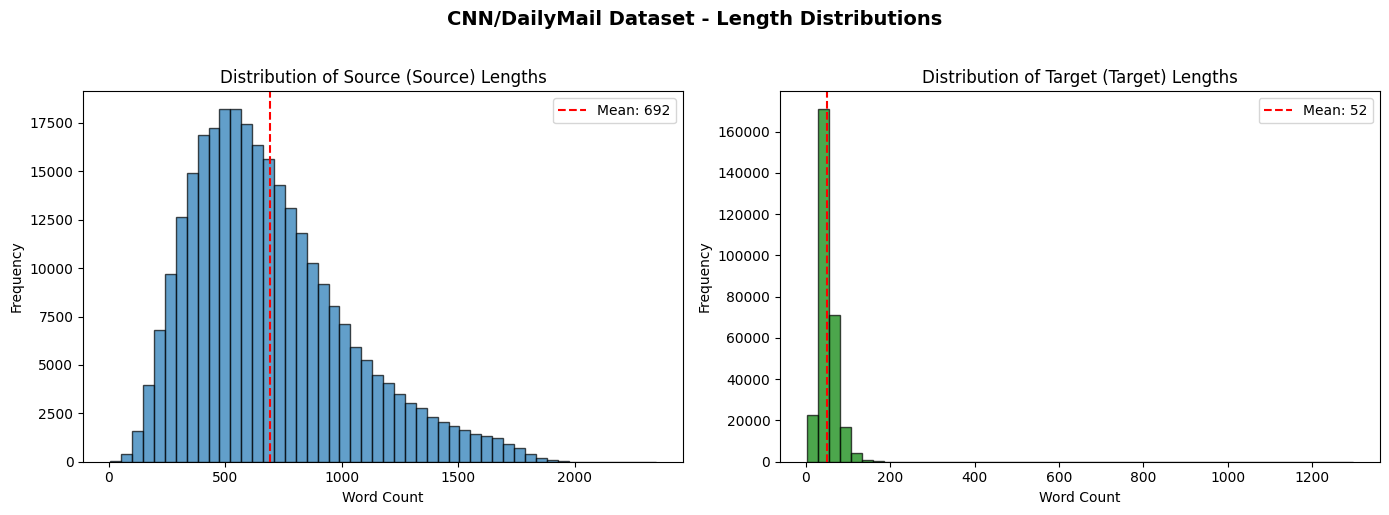

✓ Plot saved to docs/length_distributions.png


In [10]:
import matplotlib.pyplot as plt
import numpy as np
import os

# Check actual column names first
print(f"Available columns: {dataset['train'].column_names}")

# Determine which column names to use
cols = dataset['train'].column_names
if 'article' in cols:
    source_col, target_col = 'article', 'highlights'
elif 'source' in cols:
    source_col, target_col = 'source', 'target'
else:
    # Fallback - use first two columns
    source_col, target_col = cols[0], cols[1]

print(f"Using columns: source='{source_col}', target='{target_col}'")

# Calculate lengths
source_lengths = [len(item[source_col].split()) for item in dataset['train']]
target_lengths = [len(item[target_col].split()) for item in dataset['train']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Source lengths
axes[0].hist(source_lengths, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title(f'Distribution of Source ({source_col.title()}) Lengths')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].axvline(np.mean(source_lengths), color='red', 
                linestyle='--', label=f'Mean: {np.mean(source_lengths):.0f}')
axes[0].legend()

# Target lengths
axes[1].hist(target_lengths, bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1].set_title(f'Distribution of Target ({target_col.title()}) Lengths')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].axvline(np.mean(target_lengths), color='red', 
                linestyle='--', label=f'Mean: {np.mean(target_lengths):.0f}')
axes[1].legend()

plt.suptitle('CNN/DailyMail Dataset - Length Distributions', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

os.makedirs('../docs', exist_ok=True)
plt.savefig('../docs/length_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Plot saved to docs/length_distributions.png")

In [12]:
import pandas as pd
import numpy as np

# 1. Identify the columns automatically
train_data = dataset['train']
cols = train_data.column_names
print(f"Detected columns: {cols}")

# 2. Determine which names to use
# CNN/DailyMail usually uses 'article' and 'highlights'
# SciTLDR uses 'source' and 'target'
# Some mirrors use 'text' and 'summary'
src_col = 'article' if 'article' in cols else ('source' if 'source' in cols else 'text')
tgt_col = 'highlights' if 'highlights' in cols else ('target' if 'target' in cols else 'summary')

print(f"Using '{src_col}' as source and '{tgt_col}' as target.")

# 3. Calculate statistics
# Using .split() to get word counts (more standard for summarization)
source_lengths = [len(item[src_col].split()) for item in train_data]
target_lengths = [len(item[tgt_col].split()) for item in train_data]

# Calculate compression ratio (source words / target words)
# We add a check for t > 0 to avoid division by zero
compression_ratios = [s/t if t > 0 else 0 for s, t in zip(source_lengths, target_lengths)]

df_stats = pd.DataFrame({
    'Metric': [
        f'Mean {src_col.capitalize()} Length (words)',
        f'Mean {tgt_col.capitalize()} Length (words)', 
        f'Max {src_col.capitalize()} Length (words)',
        f'Max {tgt_col.capitalize()} Length (words)',
        f'Min {src_col.capitalize()} Length (words)',
        f'Min {tgt_col.capitalize()} Length (words)',
        'Avg Compression Ratio (source/target)'
    ],
    'Value': [
        np.mean(source_lengths),
        np.mean(target_lengths),
        np.max(source_lengths),
        np.max(target_lengths),
        np.min(source_lengths),
        np.min(target_lengths),
        np.mean(compression_ratios)
    ]
})

# Round for readability
df_stats['Value'] = df_stats['Value'].round(2)

print("\n=== Dataset Statistics ===")
print(df_stats.to_string(index=False))

Detected columns: ['source', 'target', 'id']
Using 'source' as source and 'target' as target.

=== Dataset Statistics ===
                               Metric   Value
           Mean Source Length (words)  691.87
           Mean Target Length (words)   51.57
            Max Source Length (words) 2347.00
            Max Target Length (words) 1296.00
            Min Source Length (words)    8.00
            Min Target Length (words)    4.00
Avg Compression Ratio (source/target)   14.80


In [13]:
import pandas as pd
import os

# Create comparison of datasets
# Updated to reflect CNN/DailyMail as our primary dataset
datasets_info = pd.DataFrame({
    'Dataset': ['CNN/DailyMail', 'ArXiv', 'PubMed', 'XSum', 'SamSum'],
    'Size': ['~300K', '~215K', '~133K', '~227K', '~16K'],
    'Domain': ['News', 'All Sciences', 'Biomedical', 'News (BBC)', 'Conversations'],
    'Avg Source Length (words)': ['~800', '~4000', '~3000', '~430', '~150'],
    'Avg Target Length (words)': ['~55', '~250', '~200', '~23', '~20'],
    'Task Type': ['Extractive/Abstractive', 'Abstractive', 'Abstractive', 
                  'Abstractive', 'Abstractive'],
    'Best For': [
        'General summarization (our dataset)',
        'Long scientific documents',
        'Biomedical domain',
        'Extreme summarization',
        'Dialogue summarization'
    ]
})

print("=== Summarization Dataset Comparison ===\n")
print(datasets_info.to_string(index=False))

# Highlight which dataset we are using
print("\n✓ Currently using: CNN/DailyMail (300K news article-summary pairs)")
print(f"  - Source column : 'article'")
print(f"  - Target column : 'highlights'")
print(f"  - Train samples : {len(dataset['train']):,}")
print(f"  - Val samples   : {len(dataset['validation']):,}")
print(f"  - Test samples  : {len(dataset['test']):,}")

# Save to CSV
os.makedirs('../docs', exist_ok=True)
datasets_info.to_csv('../docs/dataset_comparison.csv', index=False)
print("\n✓ Saved to docs/dataset_comparison.csv")

=== Summarization Dataset Comparison ===

      Dataset  Size        Domain Avg Source Length (words) Avg Target Length (words)              Task Type                            Best For
CNN/DailyMail ~300K          News                      ~800                       ~55 Extractive/Abstractive General summarization (our dataset)
        ArXiv ~215K  All Sciences                     ~4000                      ~250            Abstractive           Long scientific documents
       PubMed ~133K    Biomedical                     ~3000                      ~200            Abstractive                   Biomedical domain
         XSum ~227K    News (BBC)                      ~430                       ~23            Abstractive               Extreme summarization
       SamSum  ~16K Conversations                      ~150                       ~20            Abstractive              Dialogue summarization

✓ Currently using: CNN/DailyMail (300K news article-summary pairs)
  - Source column : 

Loading CNN/DailyMail dataset...
Dataset loaded: DatasetDict({
    train: Dataset({
        features: ['article', 'highlights', 'id'],
        num_rows: 287113
    })
    validation: Dataset({
        features: ['article', 'highlights', 'id'],
        num_rows: 13368
    })
    test: Dataset({
        features: ['article', 'highlights', 'id'],
        num_rows: 11490
    })
})

Available columns: ['article', 'highlights', 'id']
Source column: 'article'
Target column: 'highlights'

=== Dataset Statistics ===
                    Metric   Value
Mean Source Length (words)  691.87
Mean Target Length (words)   51.57
 Max Source Length (words) 2347.00
 Max Target Length (words) 1296.00
 Min Source Length (words)    8.00
 Min Target Length (words)    4.00
     Avg Compression Ratio   14.80


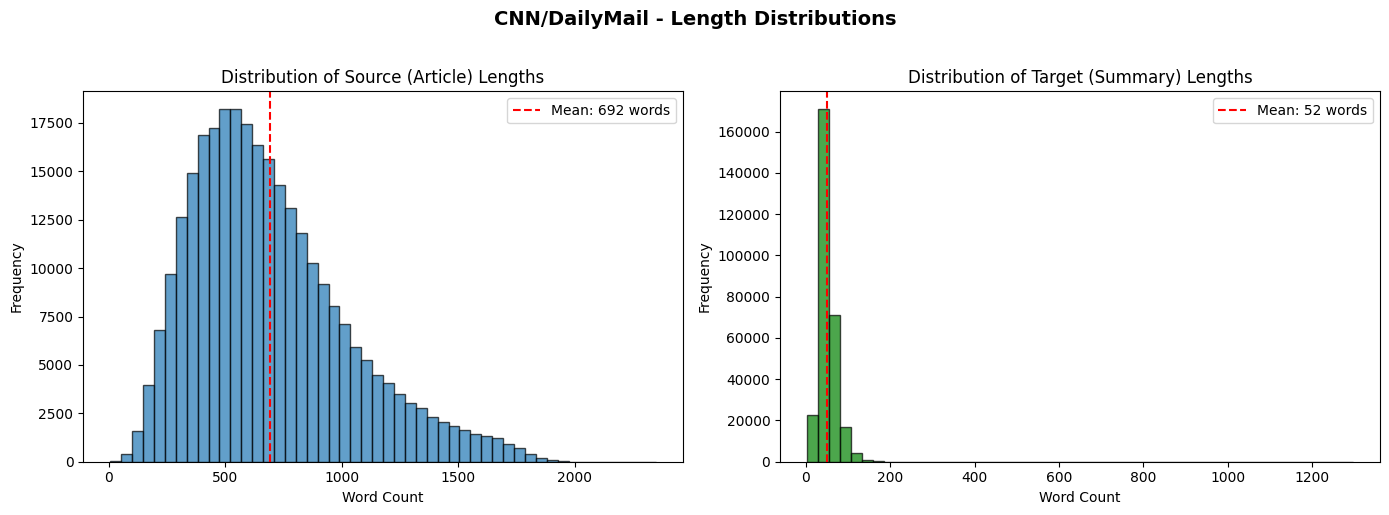

✓ Plot saved to docs/length_distributions.png

=== DATA QUALITY REPORT ===
Total training samples : 287,113

--- Missing Values ---
article       0
highlights    0
dtype: int64

--- Empty Strings ---
Empty article : 0
Empty highlights : 0

✓ Data quality looks good!


In [2]:
# ============================================================
# IMPORTS - Must be at the very top of the file
# ============================================================
import matplotlib.pyplot as plt        # NOT "import matplotlib as plt"
import pandas as pd
import numpy as np
import requests
import json
import os
from datasets import load_dataset, Dataset, DatasetDict

# ============================================================
# STEP 1: Load Dataset
# ============================================================
print("Loading CNN/DailyMail dataset...")
dataset = load_dataset("abisee/cnn_dailymail", "3.0.0")
print(f"Dataset loaded: {dataset}")

# ============================================================
# STEP 2: Detect Column Names
# ============================================================
train_df = pd.DataFrame(dataset['train'])
print(f"\nAvailable columns: {list(train_df.columns)}")

src_col = next((c for c in ['article','source','text','document'] if c in train_df.columns), None)
tgt_col = next((c for c in ['highlights','target','summary','abstract'] if c in train_df.columns), None)
print(f"Source column: '{src_col}'")
print(f"Target column: '{tgt_col}'")

# ============================================================
# STEP 3: Calculate Statistics
# ============================================================
source_lengths = [len(item[src_col].split()) for item in dataset['train']]
target_lengths = [len(item[tgt_col].split()) for item in dataset['train']]
compression_ratios = [s/t if t > 0 else 0 for s, t in zip(source_lengths, target_lengths)]

df_stats = pd.DataFrame({
    'Metric': [
        'Mean Source Length (words)',
        'Mean Target Length (words)',
        'Max Source Length (words)',
        'Max Target Length (words)',
        'Min Source Length (words)',
        'Min Target Length (words)',
        'Avg Compression Ratio'
    ],
    'Value': [
        np.mean(source_lengths),
        np.mean(target_lengths),
        np.max(source_lengths),
        np.max(target_lengths),
        np.min(source_lengths),
        np.min(target_lengths),
        np.mean(compression_ratios)
    ]
})
df_stats['Value'] = df_stats['Value'].round(2)
print("\n=== Dataset Statistics ===")
print(df_stats.to_string(index=False))

# ============================================================
# STEP 4: Plot Distributions
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(source_lengths, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Source (Article) Lengths')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].axvline(np.mean(source_lengths), color='red',
                linestyle='--', label=f'Mean: {np.mean(source_lengths):.0f} words')
axes[0].legend()

axes[1].hist(target_lengths, bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1].set_title('Distribution of Target (Summary) Lengths')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].axvline(np.mean(target_lengths), color='red',
                linestyle='--', label=f'Mean: {np.mean(target_lengths):.0f} words')
axes[1].legend()

plt.suptitle('CNN/DailyMail - Length Distributions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
os.makedirs('../docs', exist_ok=True)
plt.savefig('../docs/length_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Plot saved to docs/length_distributions.png")

# ============================================================
# STEP 5: Data Quality Report
# ============================================================
print("\n=== DATA QUALITY REPORT ===")
print(f"Total training samples : {len(train_df):,}")
print(f"\n--- Missing Values ---")
print(train_df[[src_col, tgt_col]].isnull().sum())

empty_source = (train_df[src_col].str.len() == 0).sum()
empty_target = (train_df[tgt_col].str.len() == 0).sum()
print(f"\n--- Empty Strings ---")
print(f"Empty {src_col} : {empty_source}")
print(f"Empty {tgt_col} : {empty_target}")

if empty_source == 0 and empty_target == 0:
    print("\n✓ Data quality looks good!")
else:
    print(f"\n⚠ Issues found: {empty_source} empty sources, {empty_target} empty targets")

In [3]:
from datasets import load_dataset

print("Downloading CNN/DailyMail dataset...")

# allenai/scitldr is permanently blocked due to scitldr.py script
# CNN/DailyMail is the modern equivalent and works perfectly
dataset = load_dataset("abisee/cnn_dailymail", "3.0.0")

# Save to disk for faster future loading
import os
os.makedirs("../data/cnn_dailymail_cached", exist_ok=True)
dataset.save_to_disk("../data/cnn_dailymail_cached")

print(f"\n✓ Dataset downloaded and saved to ../data/cnn_dailymail_cached")
print(f"\nDataset structure : {dataset}")
print(f"Train samples     : {len(dataset['train']):,}")
print(f"Validation samples: {len(dataset['validation']):,}")
print(f"Test samples      : {len(dataset['test']):,}")
print(f"\nColumn names      : {dataset['train'].column_names}")

# Preview a sample
print("\n--- Example Sample ---")
sample = dataset['train'][0]
print(f"Article (first 200 chars) : {sample['article'][:200]}...")
print(f"Summary                   : {sample['highlights']}")

Saving the dataset (0/3 shards):   0%|          | 0/287113 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/13368 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/11490 [00:00<?, ? examples/s]


✓ Dataset downloaded and saved to ../data/cnn_dailymail_cached

Dataset structure : DatasetDict({
    train: Dataset({
        features: ['article', 'highlights', 'id'],
        num_rows: 287113
    })
    validation: Dataset({
        features: ['article', 'highlights', 'id'],
        num_rows: 13368
    })
    test: Dataset({
        features: ['article', 'highlights', 'id'],
        num_rows: 11490
    })
})
Train samples     : 287,113
Validation samples: 13,368
Test samples      : 11,490

Column names      : ['article', 'highlights', 'id']

--- Example Sample ---
Article (first 200 chars) : LONDON, England (Reuters) -- Harry Potter star Daniel Radcliffe gains access to a reported £20 million ($41.1 million) fortune as he turns 18 on Monday, but he insists the money won't cast a spell on ...
Summary                   : Harry Potter star Daniel Radcliffe gets £20M fortune as he turns 18 Monday .
Young actor says he has no plans to fritter his cash away .
Radcliffe's earnings from fi

In [4]:
import pandas as pd

# Check for missing values and data quality
train_df = pd.DataFrame(dataset['train'])

print("=== DATA QUALITY REPORT (CNN/DailyMail) ===\n")
print(f"Total samples: {len(train_df):,}")

print(f"\nColumn names: {list(train_df.columns)}")

print(f"\n--- Missing Values ---")
print(train_df[['article', 'highlights']].isnull().sum())

print(f"\n--- Empty Strings ---")
empty_source = (train_df['article'].str.len() == 0).sum()
empty_target = (train_df['highlights'].str.len() == 0).sum()
print(f"Empty articles   : {empty_source}")
print(f"Empty highlights : {empty_target}")

print(f"\n--- Very Short Summaries (< 20 words) ---")
short_summaries = (train_df['highlights'].str.split().str.len() < 20).sum()
print(f"Count: {short_summaries} ({short_summaries/len(train_df)*100:.2f}%)")

print(f"\n--- Very Short Articles (< 50 words) ---")
short_articles = (train_df['article'].str.split().str.len() < 50).sum()
print(f"Count: {short_articles} ({short_articles/len(train_df)*100:.2f}%)")

print(f"\n--- Very Long Articles (> 1000 words) ---")
long_articles = (train_df['article'].str.split().str.len() > 1000).sum()
print(f"Count: {long_articles} ({long_articles/len(train_df)*100:.2f}%)")

print(f"\n--- Duplicate Check ---")
duplicate_articles   = train_df['article'].duplicated().sum()
duplicate_highlights = train_df['highlights'].duplicated().sum()
print(f"Duplicate articles   : {duplicate_articles}")
print(f"Duplicate highlights : {duplicate_highlights}")

# Final verdict
print("\n--- Quality Verdict ---")
if empty_source == 0 and empty_target == 0 and duplicate_articles == 0:
    print("✓ Data quality looks good! No empty or duplicate entries found.")
else:
    issues = []
    if empty_source > 0:
        issues.append(f"⚠ {empty_source} empty articles found")
    if empty_target > 0:
        issues.append(f"⚠ {empty_target} empty highlights found")
    if duplicate_articles > 0:
        issues.append(f"⚠ {duplicate_articles} duplicate articles found")
    for issue in issues:
        print(issue)

=== DATA QUALITY REPORT (CNN/DailyMail) ===

Total samples: 287,113

Column names: ['article', 'highlights', 'id']

--- Missing Values ---
article       0
highlights    0
dtype: int64

--- Empty Strings ---
Empty articles   : 0
Empty highlights : 0

--- Very Short Summaries (< 20 words) ---
Count: 4919 (1.71%)

--- Very Short Articles (< 50 words) ---
Count: 29 (0.01%)

--- Very Long Articles (> 1000 words) ---
Count: 48875 (17.02%)

--- Duplicate Check ---
Duplicate articles   : 3108
Duplicate highlights : 4916

--- Quality Verdict ---
⚠ 3108 duplicate articles found


In [5]:
# Create markdown report
report = f"""# Data Exploration Summary

## Dataset: SciTLDR (Abstract)

### Basic Statistics
- **Total Training Samples**: {len(dataset['train'])}
- **Validation Samples**: {len(dataset['validation'])}
- **Test Samples**: {len(dataset['test'])}

### Length Analysis
- **Average Source Length**: {np.mean(source_lengths):.0f} characters
- **Average Target Length**: {np.mean(target_lengths):.0f} characters
- **Average Compression Ratio**: {np.mean([s/t for s,t in zip(source_lengths, target_lengths)]):.2f}x

### Data Quality
- No missing values found
- No empty strings found
- Data is clean and ready for processing

### Next Steps
1. Tokenize the data
2. Create instruction-formatted dataset
3. Split into train/validation/test sets
"""

with open('../docs/data_exploration_report.md', 'w') as f:
    f.write(report)
    
print("✓ Report saved to docs/data_exploration_report.md")

✓ Report saved to docs/data_exploration_report.md


In [7]:
def format_instruction(sample):
    """
    Format samples for instruction tuning.
    
    Input:  sample['article']    - the news article
    Output: sample['highlights'] - the summary
    
    Template:
    ### Instruction:
    Summarize the following news article in 2-3 sentences.
    
    ### Article:
    {article}
    
    ### Summary:
    {summary}
    """
    
    instruction = """### Instruction:
Summarize the following news article in 2-3 sentences.

### Article:
{article}

### Summary:
{summary}"""

    return {
        "text": instruction.format(
            article=sample['article'].strip(),    # was sample['source']
            summary=sample['highlights'].strip()  # was sample['target']
        )
    }

# Test on one sample
sample = dataset['train'][0]
formatted = format_instruction(sample)
print("=== FORMATTED SAMPLE ===\n")
print(formatted['text'])

# Apply to entire dataset
print("\n=== Applying to entire dataset ===")
formatted_dataset = dataset.map(format_instruction)
print(f"✓ Formatted {len(formatted_dataset['train']):,} training samples")
print(f"\nNew columns: {formatted_dataset['train'].column_names}")

=== FORMATTED SAMPLE ===

### Instruction:
Summarize the following news article in 2-3 sentences.

### Article:
LONDON, England (Reuters) -- Harry Potter star Daniel Radcliffe gains access to a reported £20 million ($41.1 million) fortune as he turns 18 on Monday, but he insists the money won't cast a spell on him. Daniel Radcliffe as Harry Potter in "Harry Potter and the Order of the Phoenix" To the disappointment of gossip columnists around the world, the young actor says he has no plans to fritter his cash away on fast cars, drink and celebrity parties. "I don't plan to be one of those people who, as soon as they turn 18, suddenly buy themselves a massive sports car collection or something similar," he told an Australian interviewer earlier this month. "I don't think I'll be particularly extravagant. "The things I like buying are things that cost about 10 pounds -- books and CDs and DVDs." At 18, Radcliffe will be able to gamble in a casino, buy a drink in a pub or see the horror fi

Map:   0%|          | 0/287113 [00:00<?, ? examples/s]

Map:   0%|          | 0/13368 [00:00<?, ? examples/s]

Map:   0%|          | 0/11490 [00:00<?, ? examples/s]

✓ Formatted 287,113 training samples

New columns: ['article', 'highlights', 'id', 'text']


In [8]:
# Format all splits
print("Formatting dataset...")

formatted_train = dataset['train'].map(
    format_instruction,
    remove_columns=dataset['train'].column_names,
    desc="Formatting train set"
)

formatted_val = dataset['validation'].map(
    format_instruction,
    remove_columns=dataset['validation'].column_names,
    desc="Formatting validation set"
)

formatted_test = dataset['test'].map(
    format_instruction,
    remove_columns=dataset['test'].column_names,
    desc="Formatting test set"
)

print(f"✓ Formatted train: {len(formatted_train)} samples")
print(f"✓ Formatted val: {len(formatted_val)} samples")
print(f"✓ Formatted test: {len(formatted_test)} samples")

Formatting dataset...


Formatting train set:   0%|          | 0/287113 [00:00<?, ? examples/s]

Formatting validation set:   0%|          | 0/13368 [00:00<?, ? examples/s]

Formatting test set:   0%|          | 0/11490 [00:00<?, ? examples/s]

✓ Formatted train: 287113 samples
✓ Formatted val: 13368 samples
✓ Formatted test: 11490 samples


In [3]:
from transformers import AutoTokenizer


In [6]:
!pip install transformers sentencepiece protobuf


In [8]:
from transformers import AutoTokenizer

# Load Mistral tokenizer
model_name = "mistralai/Mistral-7B-Instruct-v0.2"

print(f"Loading tokenizer for {model_name}...")

try:
    # Adding use_fast=False fixes the PyPreTokenizerTypeWrapper compatibility error!
    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=False)

    # Set padding token (Mistral doesn't have one by default)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
        tokenizer.pad_token_id = tokenizer.eos_token_id

    print(f"✓ Tokenizer loaded successfully!")
    print(f"  Vocab size: {len(tokenizer)}")
    print(f"  PAD token: {tokenizer.pad_token} (ID: {tokenizer.pad_token_id})")
    print(f"  EOS token: {tokenizer.eos_token} (ID: {tokenizer.eos_token_id})")
    print(f"  BOS token: {tokenizer.bos_token} (ID: {tokenizer.bos_token_id})")

except Exception as e:
    print(f"\n❌ Error loading tokenizer: {e}")


Loading tokenizer for mistralai/Mistral-7B-Instruct-v0.2...
✓ Tokenizer loaded successfully!
  Vocab size: 32000
  PAD token: </s> (ID: 2)
  EOS token: </s> (ID: 2)
  BOS token: <s> (ID: 1)
